# Imports

In [1]:
import os
import warnings
from rich import print

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import palantir
import scvi
import torch

In [2]:
plt.rcParams['savefig.dpi'] = 300
%matplotlib inline

# Functions

In [22]:
def log_transform(ad, ps=0.1):
    """
    Applies a pseudo-count log2 transformation to the data in an AnnData object.

    The transformation is defined as log2(x + ps) - log2(ps), where x is the original data
    and ps is the pseudo-count. The purpose of the pseudo-count is to avoid taking the log of zero.

    Parameters
    ----------
    ad: AnnData
        The AnnData object containing the data to be transformed.

    ps: float, optional
        The pseudo-count to be added to the data before taking the logarithm.
        The default value is 0.1.

    Returns
    -------
    None
        The function modifies the AnnData object in-place.
    """

    # Check if the data in the Anndata object is a numpy array
    if not isinstance(ad.X.data, np.ndarray):
        raise TypeError("The data in the AnnData object should be a numpy array.")

    # Check if the pseudo-count is a positive number
    if ps <= 0:
        raise ValueError("The pseudo-count should be a positive number.")

    # Apply the log2 transformation
    ad.X.data = np.log2(ad.X.data + ps) - np.log2(ps)

# Load Data

In [3]:
input_dir = '/fh/fast/talbot_j/grp/TalbotLab/Current_Lab_Members/Brandon_Nguyen/Project/Results/BN007/datasets/Wang et al/GSE260708_filtered_feature_bc_matrix.PBSxINF/filtered_feature_bc_matrix/'

In [4]:
# Load in matrix to an AnnData object
hto_ad = sc.read(input_dir + 'matrix.mtx.gz')
hto_ad

AnnData object with n_obs × n_vars = 32296 × 21294

In [5]:
hto_barcodes = pd.read_csv(input_dir + 'barcodes.tsv.gz', sep='\t', header=None) 
hto_barcodes = hto_barcodes.rename(columns={0:'barcode'})

In [6]:
hto_genes = pd.read_csv(input_dir + 'features.tsv.gz', sep='\t', header=None) 
hto_genes = hto_genes.rename(columns={0:'gene_id', 1: 'gene_name', 2: 'feature_types'})

In [7]:
hto_ad = hto_ad.T 
hto_ad.obs = hto_barcodes
hto_ad.var = hto_genes
hto_ad.var_names_make_unique()
hto_ad

AnnData object with n_obs × n_vars = 21294 × 32296
    obs: 'barcode'
    var: 'gene_id', 'gene_name', 'feature_types'

In [8]:
hto_ad.var_names = hto_ad.var['gene_name']
hto_ad.obs_names = hto_ad.obs['barcode']
hto_ad.layers['raw_counts'] = hto_ad.X.copy()
hto_counts_df = pd.DataFrame(hto_ad.layers['raw_counts'].toarray(), index=hto_ad.obs_names, columns=hto_ad.var_names)

In [9]:
# Create an Anndata of just HTO and just RNA
hto_ad.var_names_make_unique()
hto_rna = hto_ad[:, hto_ad.var["feature_types"] == "Gene Expression"].copy()
hto_tag = hto_ad[:, hto_ad.var["feature_types"] == "Antibody Capture"].copy()

In [10]:
hto_rna.shape

(21294, 32288)

In [11]:
hto_tag.shape

(21294, 8)

# Preprocessing

In [72]:
hto_rna.var["mt"] = hto_rna.var_names.str.startswith("mt")
sc.pp.calculate_qc_metrics(
    hto_rna,
    qc_vars=["mt"],
    inplace=True,
    percent_top=None,
    log1p=False,
)

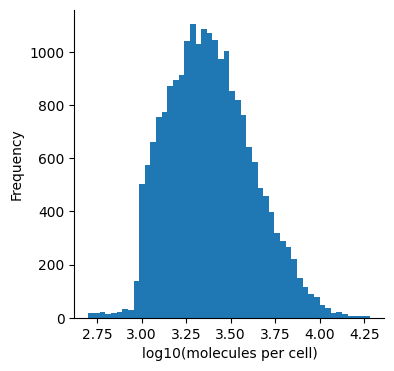

In [73]:
plt.figure()
ax = plt.gca()
ax.hist(np.log10(hto_rna.obs["total_counts"]), bins=50)
ax.set_xlabel("log10(molecules per cell)")
ax.set_ylabel("Frequency")
plt.show()

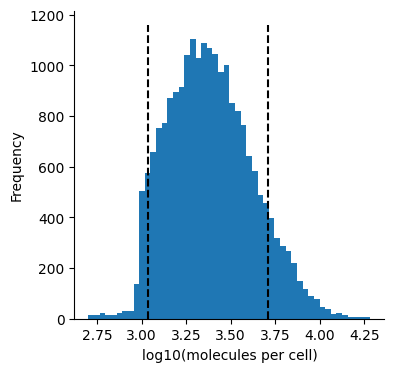

In [75]:
THRESHOLDS = np.log10(np.percentile((hto_rna.obs["total_counts"]), [5, 90]))

plt.figure()
ax = plt.gca()
ax.hist(np.log10(hto_rna.obs["total_counts"]), bins=50)
ax.vlines(
    THRESHOLDS,
    ymin=ax.get_ylim()[0],
    ymax=ax.get_ylim()[1],
    color="black",
    linestyle="--",
)
ax.set_xlabel("log10(molecules per cell)")
ax.set_ylabel("Frequency")
plt.show()

In [76]:
use_cells = hto_rna.obs_names[
    (np.log10(hto_rna.obs["total_counts"]) > THRESHOLDS[0])
    & (np.log10(hto_rna.obs["total_counts"]) < THRESHOLDS[1])
]
hto_rna = hto_rna[use_cells, :]

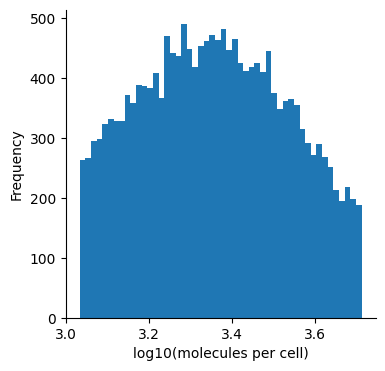

In [77]:
plt.figure()
ax = plt.gca()
ax.hist(np.log10(hto_rna.obs["total_counts"]), bins=50)
ax.set_xlabel("log10(molecules per cell)")
ax.set_ylabel("Frequency")
plt.show()

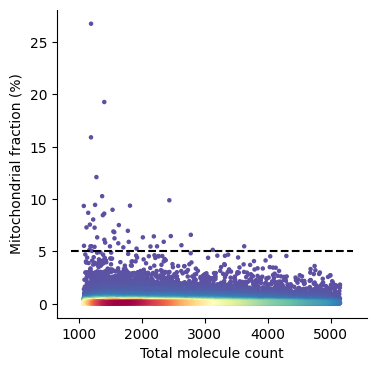

In [78]:
MITO_THRESHOLD = 5
x, y, dens = palantir.plot.density_2d(hto_rna.obs["total_counts"], hto_rna.obs["pct_counts_mt"])

plt.figure()
ax = plt.gca()
ax.scatter(x, y, c=dens, s=5)
ax.hlines(
    MITO_THRESHOLD,
    xmin=ax.get_xlim()[0],
    xmax=ax.get_xlim()[1],
    colors="black",
    linestyles="--",
)
plt.xlabel("Total molecule count")
plt.ylabel("Mitochondrial fraction (%)")
plt.show()

In [79]:
hto_rna = hto_rna[hto_rna.obs["pct_counts_mt"] < MITO_THRESHOLD, :]

In [80]:
sc.pp.filter_genes(hto_rna, min_cells=50)

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:284: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [81]:
hto_rna.shape

(18061, 15876)

In [82]:
sc.pp.normalize_total(hto_rna)
hto_rna.layers["normalized_counts"] = hto_rna.X.copy()
log_transform(hto_rna)
hto_rna.layers["logcounts"] = hto_rna.X.copy()

In [83]:
sc.pp.highly_variable_genes(hto_rna, flavor="cell_ranger", n_top_genes=2500)

In [84]:
sc.tl.pca(hto_rna, mask_var="highly_variable")

In [85]:
sc.pp.neighbors(hto_rna, use_rep="X_pca")
sc.tl.umap(hto_rna)

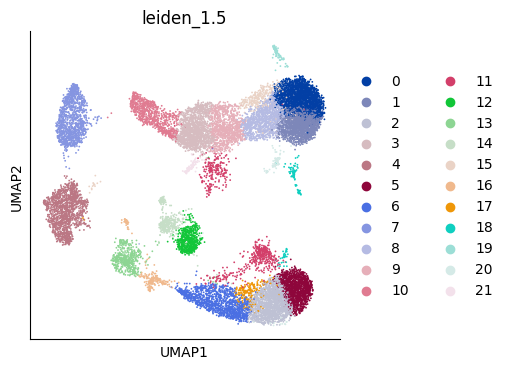

In [86]:
sc.tl.leiden(hto_rna, resolution=1.5, key_added="leiden_1.5")
sc.pl.umap(hto_rna, color="leiden_1.5")

In [87]:
sc.pp.scrublet(hto_rna)

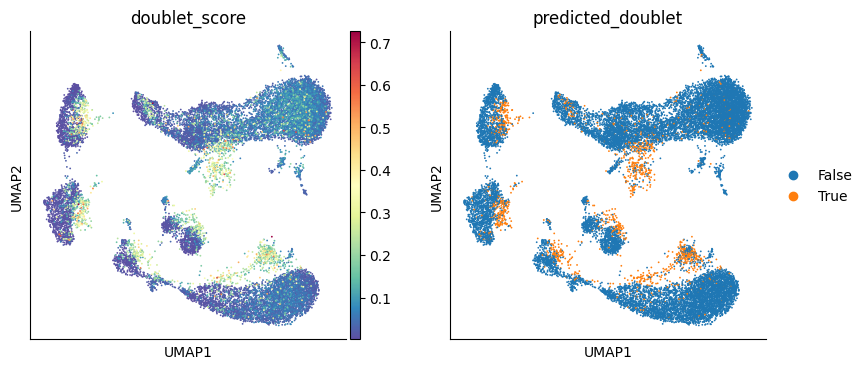

In [88]:
sc.pl.umap(hto_rna, color=["doublet_score", "predicted_doublet"])

In [89]:
# Keep only singlets
hto_rna_singlets = hto_rna[hto_rna.obs['predicted_doublet'] == False].copy()

In [90]:
sc.pp.highly_variable_genes(hto_rna_singlets, flavor="cell_ranger", n_top_genes=2500)
sc.tl.pca(hto_rna_singlets, mask_var="highly_variable")
sc.pp.neighbors(hto_rna_singlets, use_rep="X_pca")
sc.tl.umap(hto_rna_singlets)

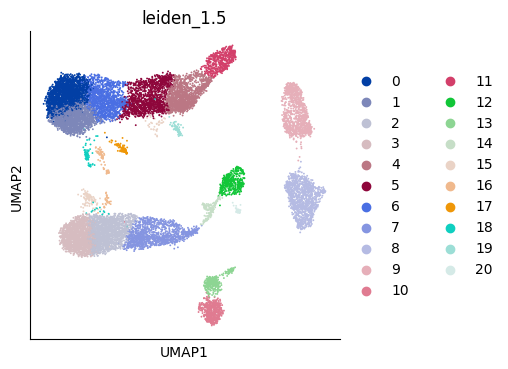

In [91]:
sc.tl.leiden(hto_rna_singlets, resolution=1.5, key_added="leiden_1.5")
sc.pl.umap(hto_rna_singlets, color="leiden_1.5")

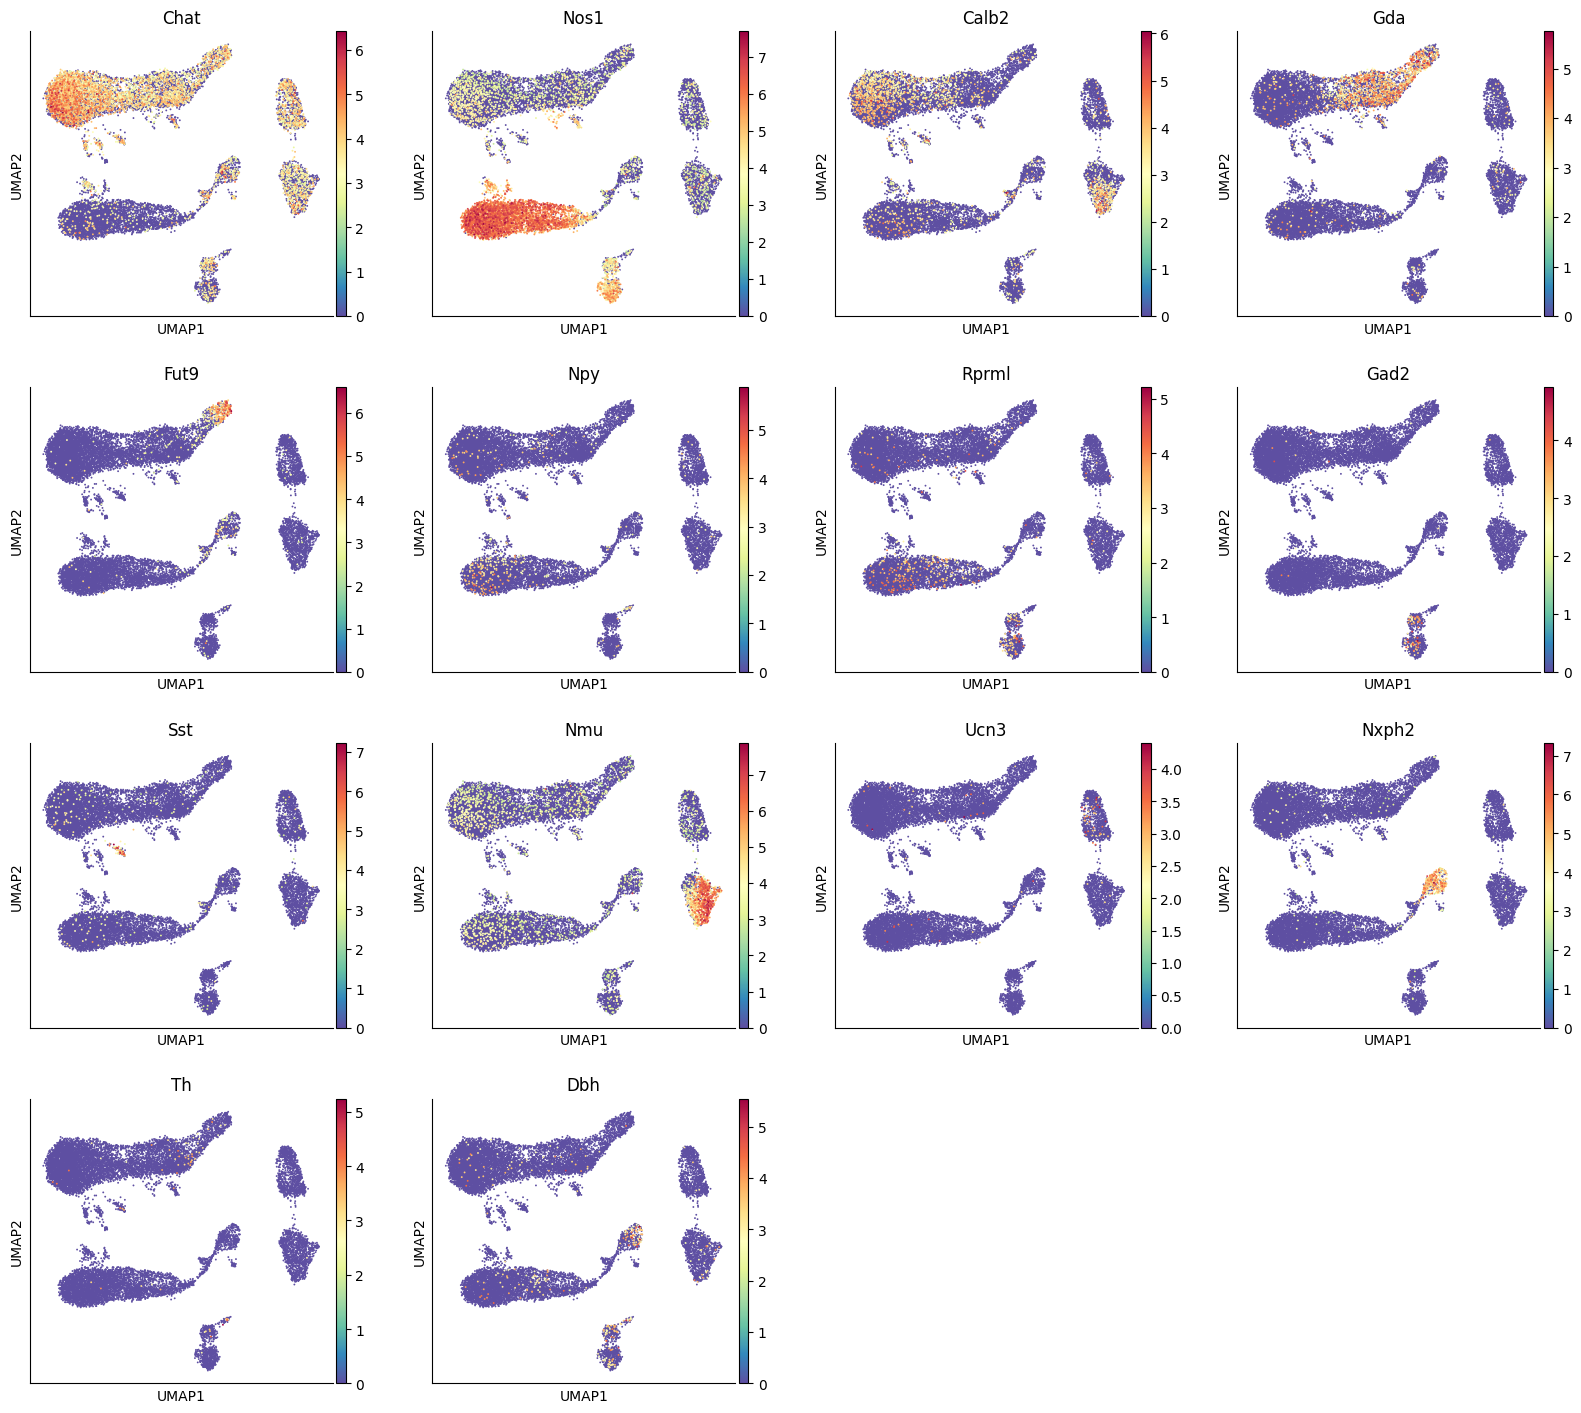

In [92]:
# Check neuronal markers
sc.pl.umap(hto_rna_singlets, color=['Chat', 'Nos1', 'Calb2', 'Gda', 'Fut9', 'Npy', 'Rprml', 'Gad2', 'Sst', 'Nmu', 'Ucn3', 'Nxph2', 'Th', 'Dbh'])

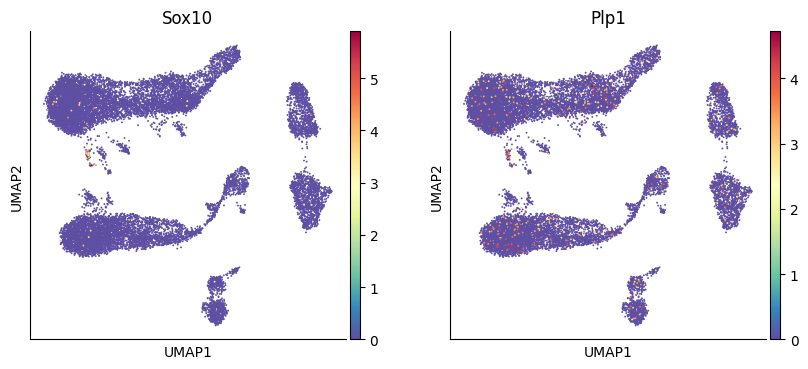

In [93]:
# Check glial markers
sc.pl.umap(hto_rna_singlets, color=['Sox10', 'Plp1'])

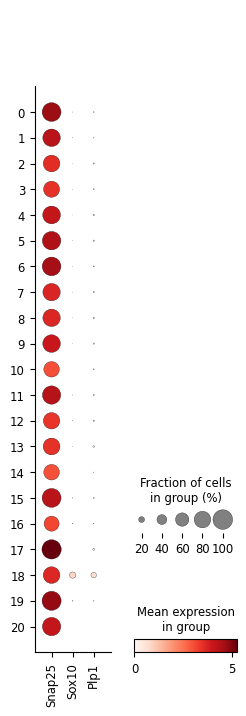

In [94]:
# Check for contaminant clusters
sc.pl.dotplot(hto_rna_singlets, ['Snap25', 'Sox10', 'Plp1'], groupby='leiden_1.5')

In [95]:
# Remove neuron-glial contaminant cluster
hto_rna_singlets = hto_rna_singlets[~hto_rna_singlets.obs['leiden_1.5'].isin(['18']),:].copy()
hto_rna_singlets.shape

(16501, 15876)

In [96]:
sc.pp.highly_variable_genes(hto_rna_singlets, flavor="cell_ranger", n_top_genes=1500)
sc.tl.pca(hto_rna_singlets, mask_var="highly_variable")
sc.pp.neighbors(hto_rna_singlets, use_rep="X_pca")
sc.tl.umap(hto_rna_singlets)

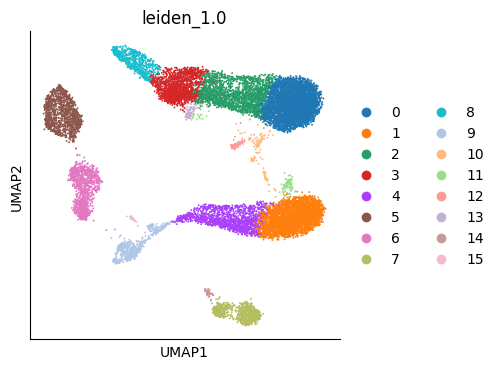

In [97]:
sc.tl.leiden(hto_rna_singlets, resolution=1.0, key_added="leiden_1.0")
sc.pl.umap(hto_rna_singlets, color="leiden_1.0")

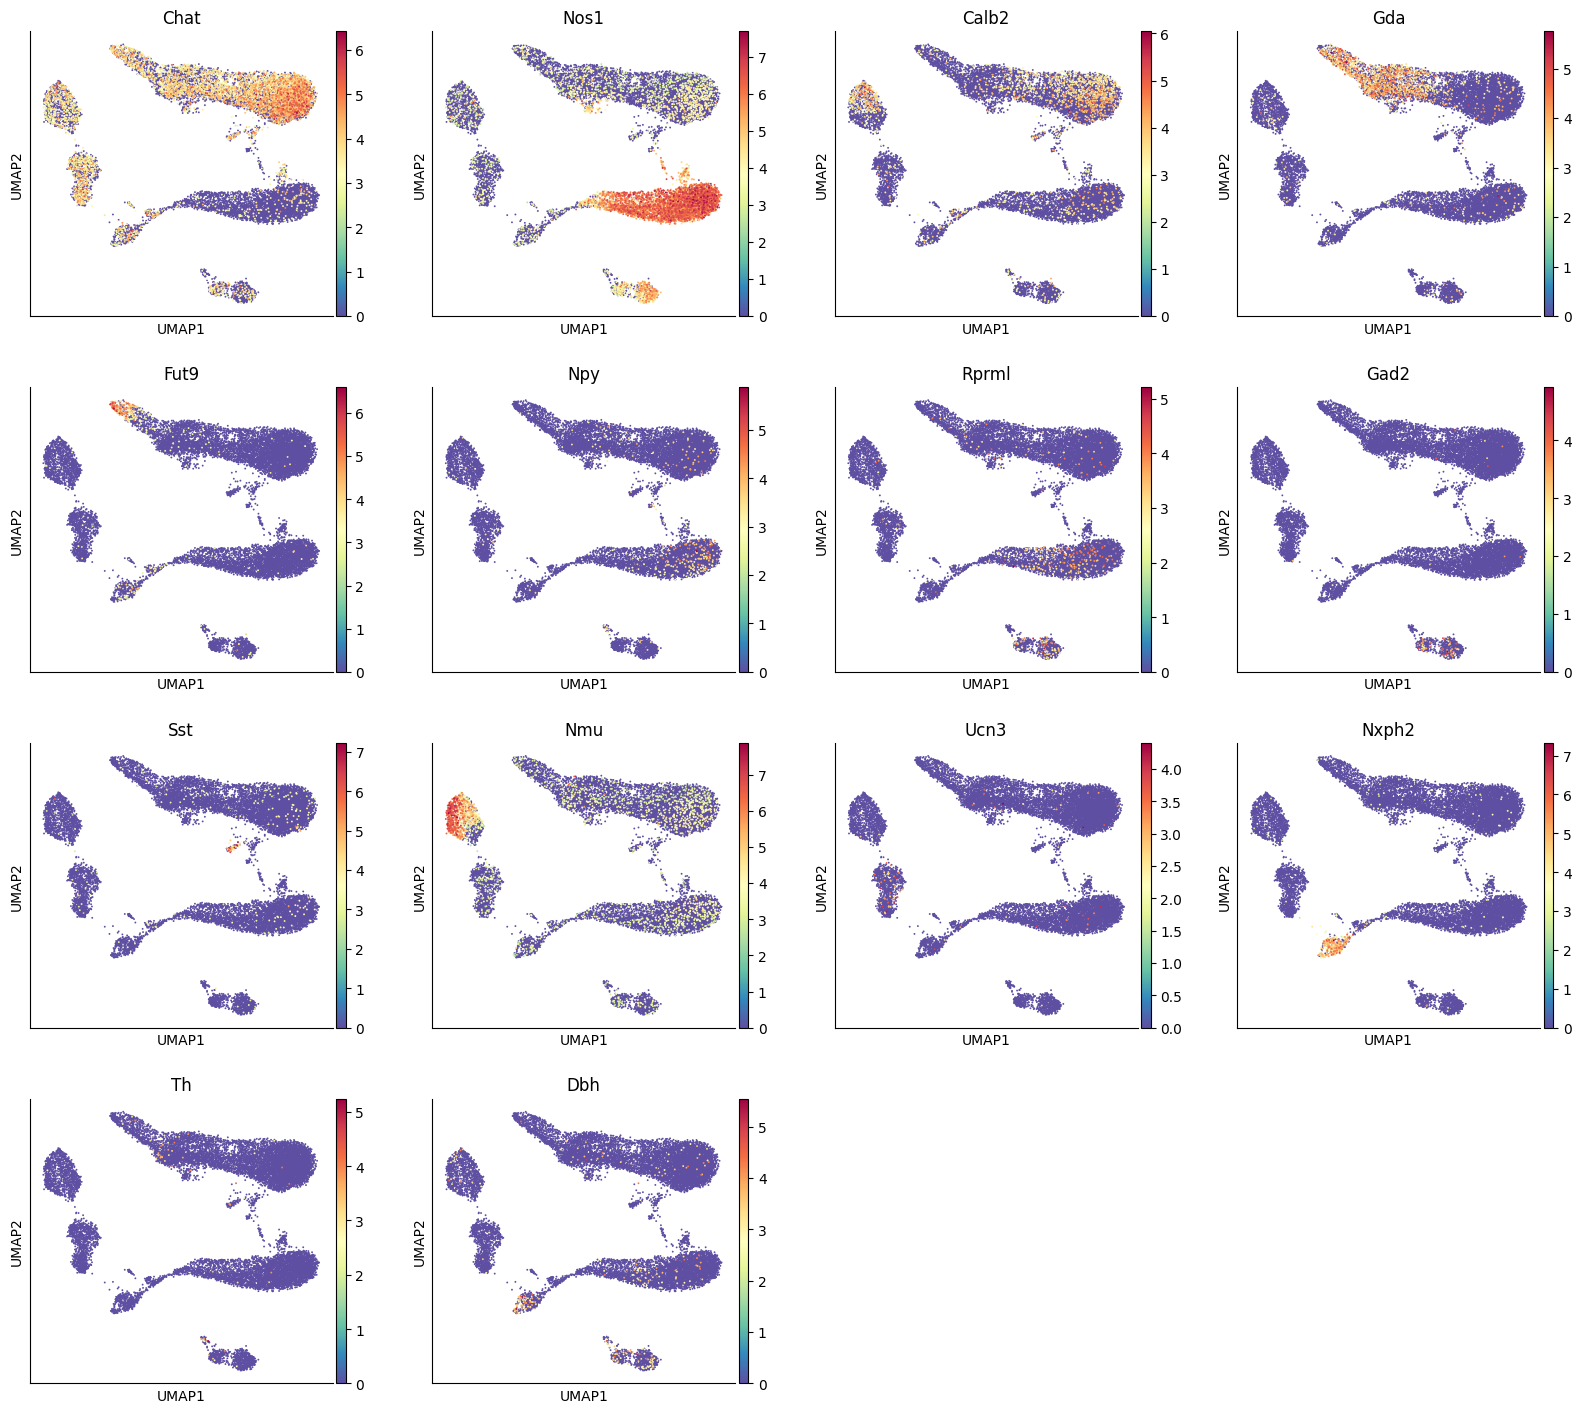

In [102]:
sc.pl.umap(hto_rna_singlets, color=['Chat', 'Nos1', 'Calb2', 'Gda', 'Fut9', 'Npy', 'Rprml', 'Gad2', 'Sst', 'Nmu', 'Ucn3', 'Nxph2', 'Th', 'Dbh'])

# Demultiplexing

In [103]:
# Subset HTO tags
hto_tag.var_names

Index(['Baf53Nb.IF1', 'Baf53Nb.IF2', 'Baf53Nb.IF3', 'Baf53Nb.IF4',
       'Baf53Nb.CL1', 'Baf53Nb.CL2', 'Baf53Nb.CL3', 'Baf53Nb.CL4'],
      dtype='object', name='gene_name')

In [104]:
hto_tag.shape

(21294, 8)

In [105]:
hto_tag = hto_tag[hto_rna_singlets.obs_names, :]
hto_tag.shape

(16501, 8)

In [106]:
hto_rna_singlets.shape

(16501, 15876)

In [107]:
sc.pp.normalize_total(hto_tag)
hto_tag.layers["normalized_counts"] = hto_tag.X.copy()
log_transform(hto_tag)
hto_tag.layers["logcounts"] = hto_tag.X.copy()

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


In [108]:
sc.tl.pca(hto_tag)

In [109]:
sc.pp.neighbors(hto_tag, use_rep="X_pca")
sc.tl.umap(hto_tag)

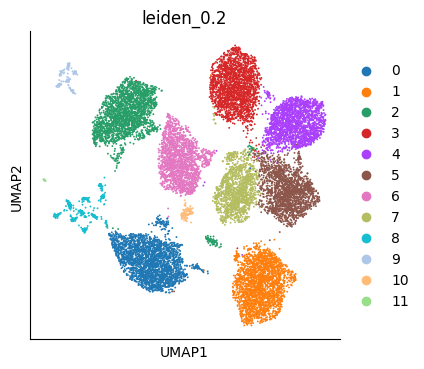

In [110]:
sc.tl.leiden(hto_tag, resolution=0.2, key_added='leiden_0.2')
sc.pl.umap(hto_tag, color=['leiden_0.2'])

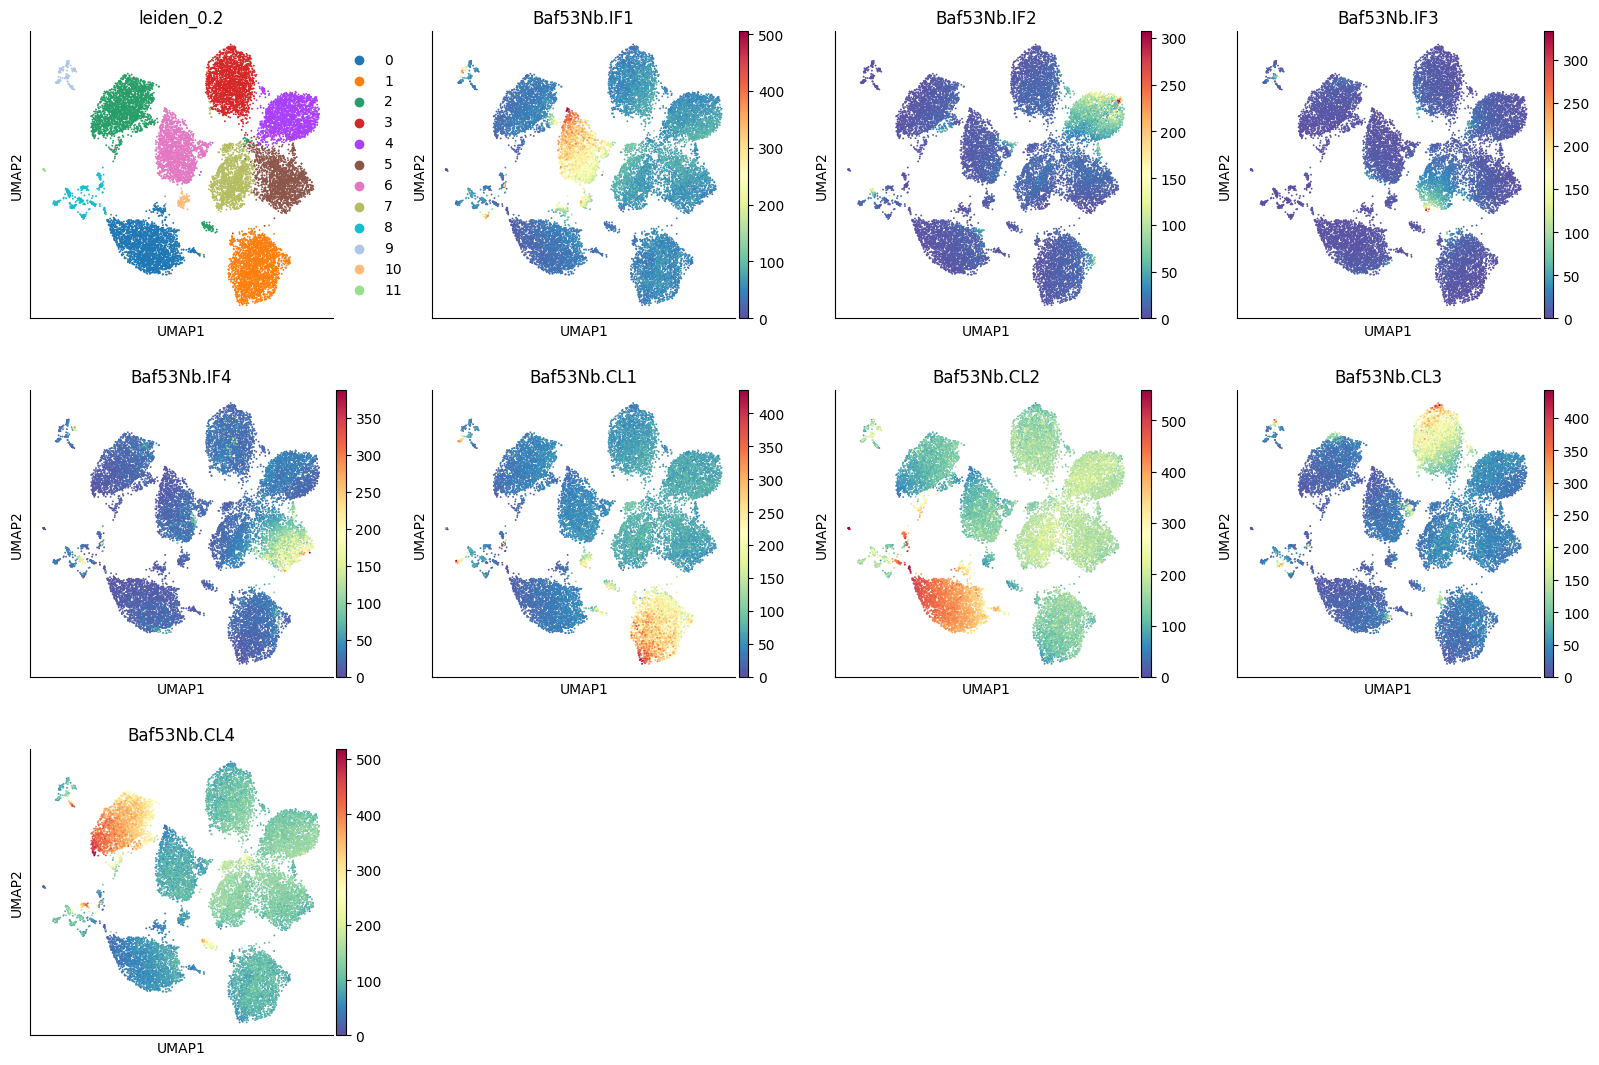

In [111]:
sc.pl.umap(hto_tag, color=['leiden_0.2'] + list(hto_tag.var_names), layer='normalized_counts')

In [112]:
# Mapping Leiden values to cell types
leiden_to_hto = {
    "0": "CL2",
    "1": "CL1",
    "2": "CL4",
    "3": "CL3",
    "4": "IF2",
    "5": "IF4",
    "6": "IF1",
    "7": "IF3",
    "8": "Unknown",
    "9": "Unknown",
    "10": "Unknown",
    "11": "Unknown"
}

# Assign cell type to each cell using the mapping
hto_tag.obs["hto_assignment"] = hto_tag.obs["leiden_0.2"].map(leiden_to_hto)

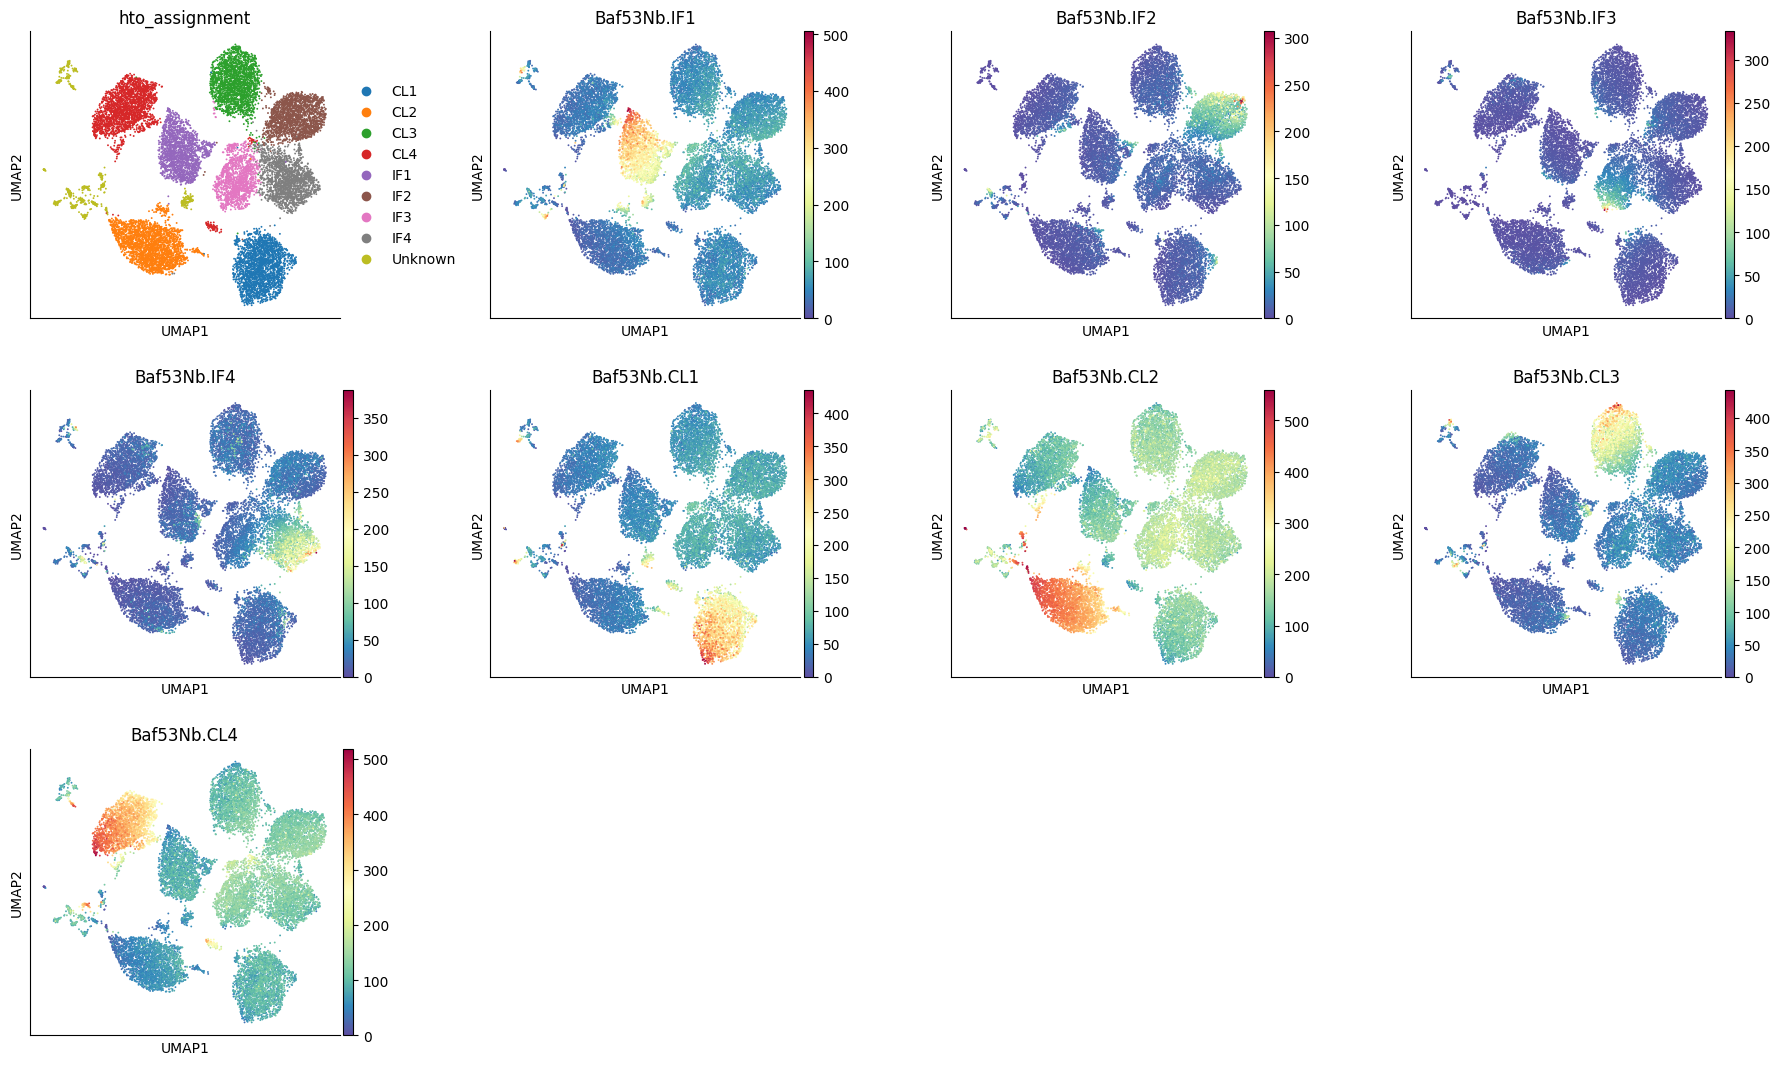

In [116]:
sc.pl.umap(hto_tag, color=['hto_assignment'] + list(hto_tag.var_names), wspace=0.35, layer='normalized_counts')

In [117]:
hto_assignments = pd.DataFrame(hto_tag.obs["hto_assignment"])
hto_assignments.head()

,hto_assignment
barcode,
AAACCCAAGCGATGAC-1,IF2
AAACCCAAGGCCCGTT-1,IF2
AAACCCAAGGTTAAAC-1,CL3
AAACCCACAACTTCTT-1,IF3
AAACCCACAAGACGAC-1,IF4


In [118]:
hto_rna_singlets.obs = hto_rna_singlets.obs.join(hto_assignments, how='inner')

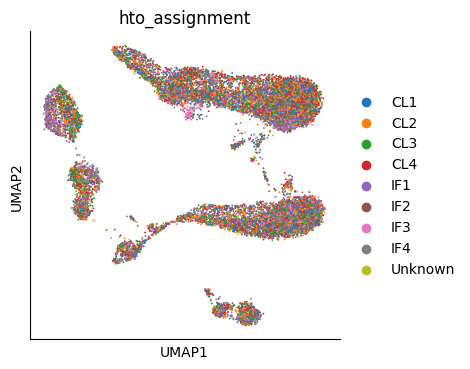

In [119]:
sc.pl.umap(hto_rna_singlets, color=['hto_assignment'])

In [120]:
# Mapping Leiden values to cell types
hto_assignment_to_condition = {
    "CL1": "PBS",
    "CL2": "PBS",
    "CL3": "PBS",
    "CL4": "PBS",
    "IF1": "Infected",
    "IF2": "Infected",
    "IF3": "Infected",
    "IF4": "Infected",
    "Unknown": "Unknown"
}

# Assign cell type to each cell using the mapping
hto_rna_singlets.obs["condition"] = hto_rna_singlets.obs["hto_assignment"].map(hto_assignment_to_condition)

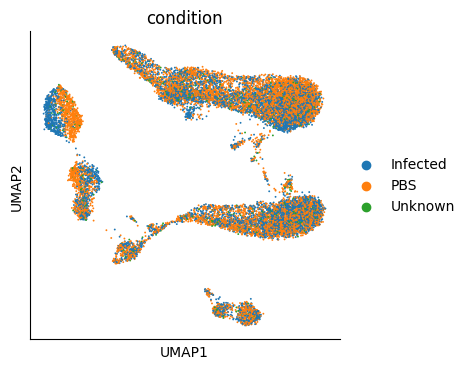

In [121]:
sc.pl.umap(hto_rna_singlets, color=['condition'])

In [122]:
ad_wang = hto_rna_singlets[hto_rna_singlets.obs['condition'] == 'PBS']

In [123]:
ad_wang.obs['condition'].unique()

['PBS']
Categories (1, object): ['PBS']

In [124]:
sc.pp.highly_variable_genes(ad_wang, flavor="cell_ranger", n_top_genes=2500)
sc.tl.pca(ad_wang, mask_var="highly_variable")
sc.pp.neighbors(ad_wang, use_rep="X_pca")
sc.tl.umap(ad_wang)

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:696: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


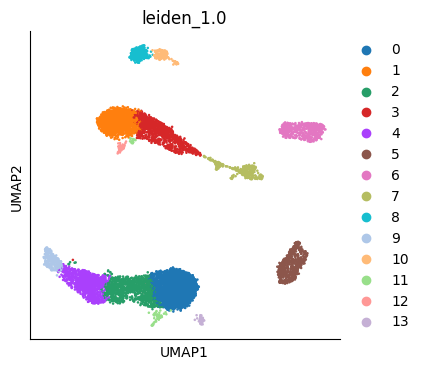

In [125]:
sc.tl.leiden(ad_wang, resolution=1.0, key_added="leiden_1.0")
sc.pl.umap(ad_wang, color="leiden_1.0")

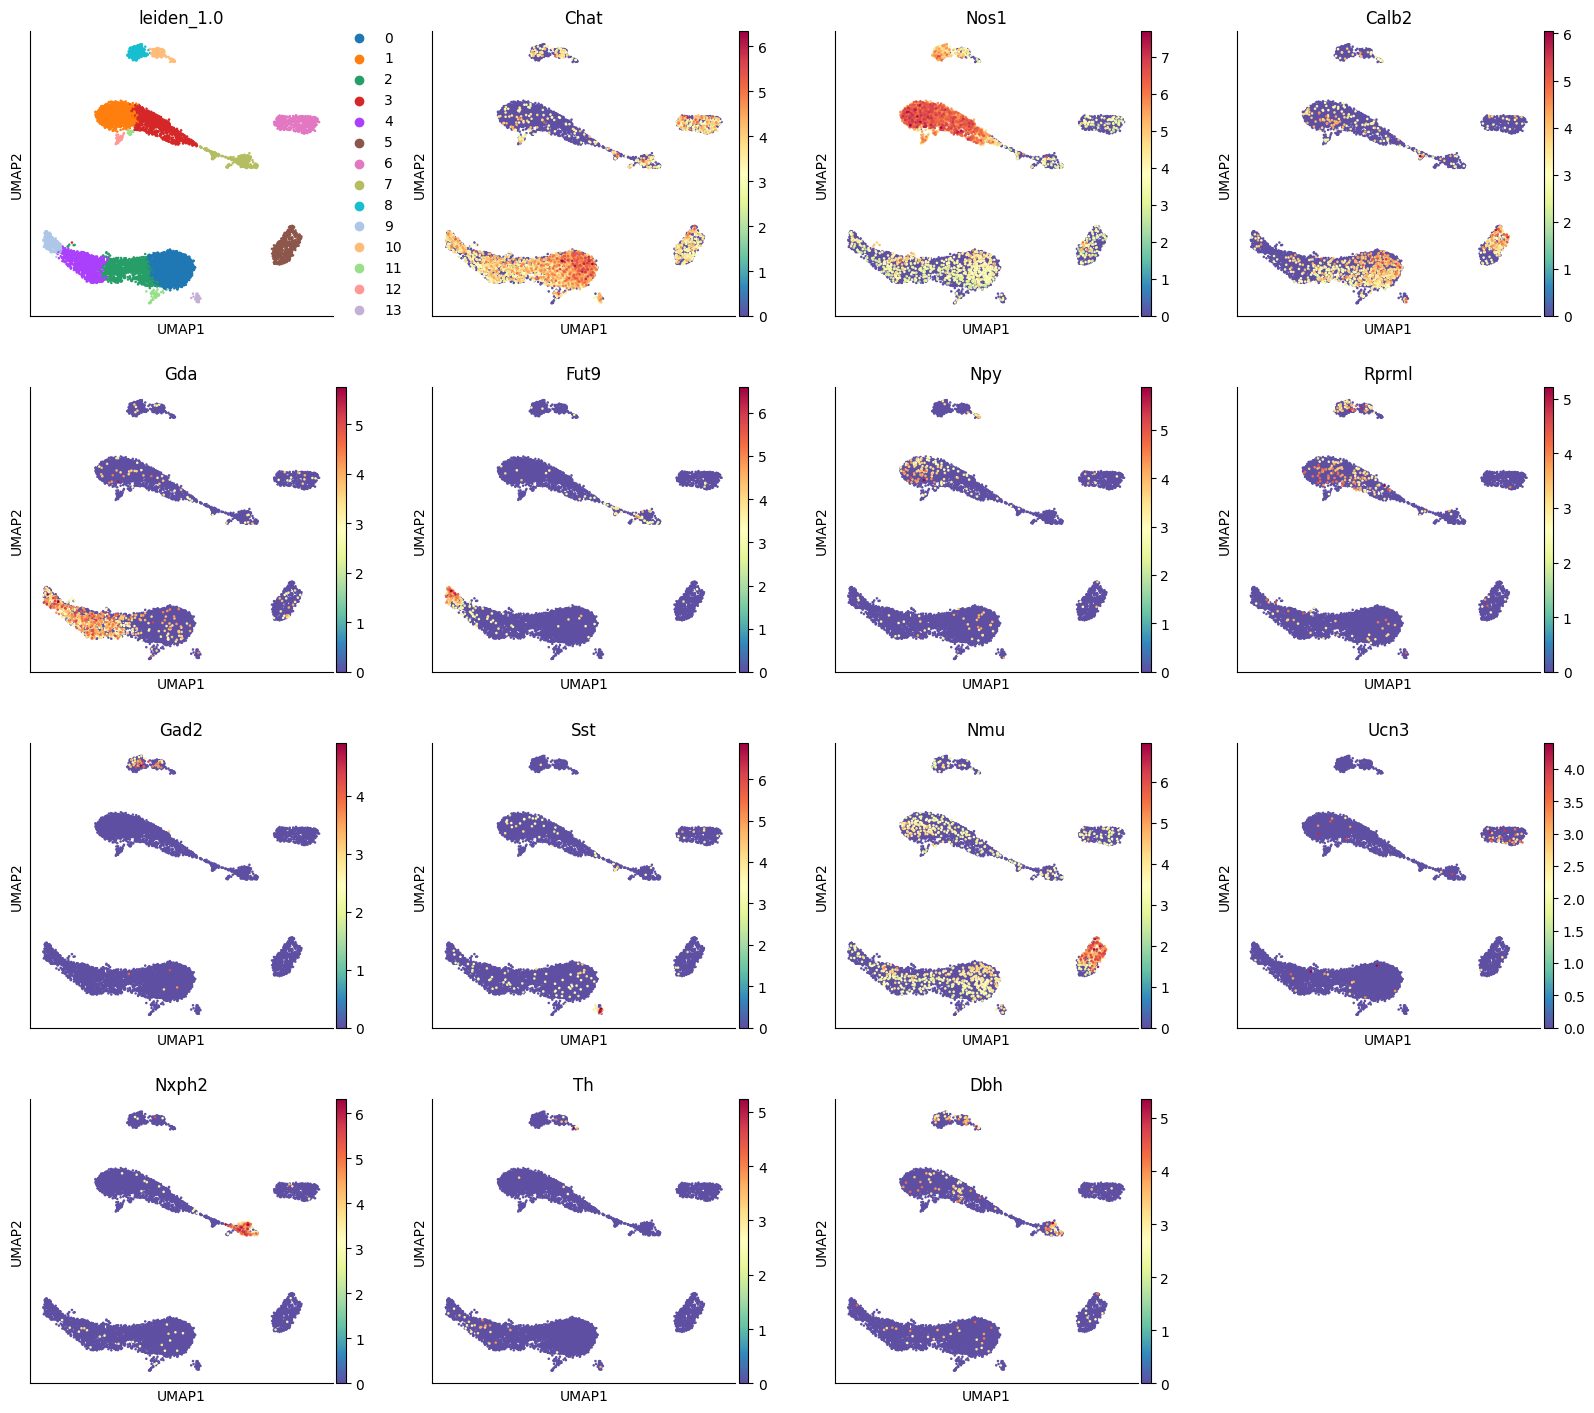

In [126]:
sc.pl.umap(ad_wang, color=['leiden_1.0', 'Chat', 'Nos1', 'Calb2', 'Gda', 'Fut9', 'Npy', 'Rprml', 'Gad2', 'Sst', 'Nmu', 'Ucn3', 'Nxph2', 'Th', 'Dbh'])

# Save AnnData Object

In [128]:
# Use gene_name as var index, drop the column, and clear the index name
ad_wang.var['gene_name'] = ad_wang.var['gene_name'].astype(str)
ad_wang.var = ad_wang.var.set_index('gene_name', drop=True)
ad_wang.var.index.name = None
ad_wang.var_names_make_unique()

# Fix .raw similarly if present
if ad_wang.raw is not None:
    _raw = ad_wang.raw.to_adata()
    _raw.var['gene_name'] = _raw.var['gene_name'].astype(str)
    _raw.var = _raw.var.set_index('gene_name', drop=True)
    _raw.var.index.name = None
    _raw.var_names_make_unique()
    ad_wang.raw = _raw

ad_wang.write_h5ad("ad_wang_preprocessed.h5ad")